In [1]:
# Cell 1 — Imports
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

# Metrics
from torchmetrics import Accuracy, F1Score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Utilities
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")
print(f"✅ PyTorch: {torch.version}")
print(f"✅ All libraries imported successfully!")

✅ Device: cpu
✅ PyTorch: <module 'torch.version' from 'c:\\Users\\jana5\\envs\\clear-face-312\\Lib\\site-packages\\torch\\version.py'>
✅ All libraries imported successfully!


Total images: 22244

Columns: ['image_id', 'image_path', 'participant_id', 'source_dataset', 'split', 'label']

Split distribution:
split
train         8009
final_test    5560
test          3337
care_dev      3337
val           2001
Name: count, dtype: int64

Label distribution:
label
surprise    4124
angry       3434
happy       3325
disgust     3233
fear        2961
sad         2793
neutral     2374
Name: count, dtype: int64


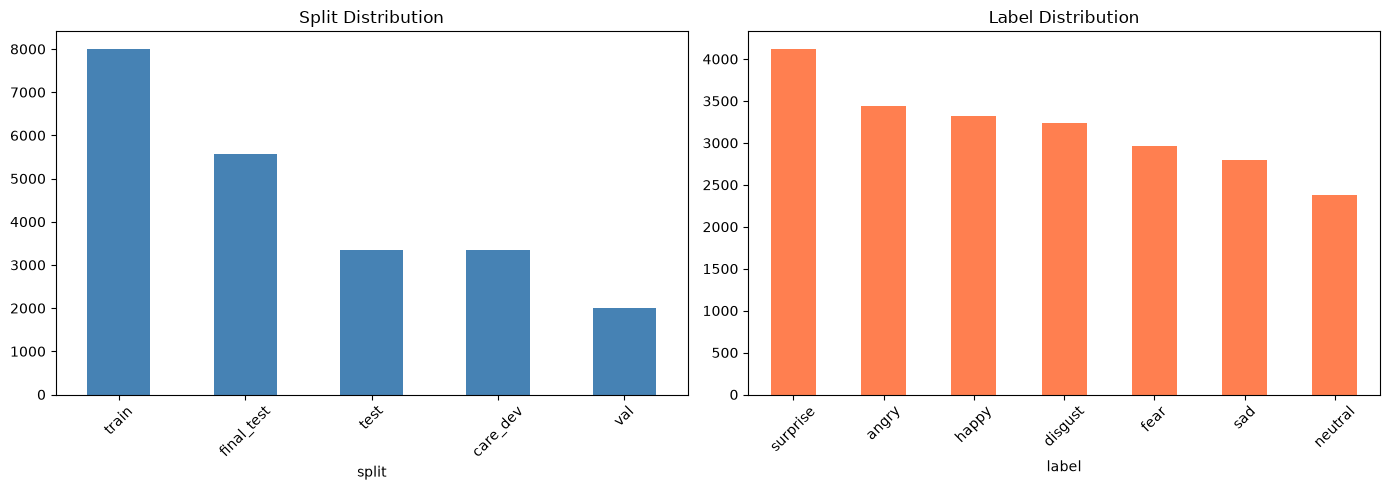

In [2]:
# Cell 2 — Load and Explore Dataset

# Load CSV
df = pd.read_csv(r"C:\Users\jana5\CLEAR-Face\data\milestone_2\metadata\dataset_manifest.csv")
# Basic info
print(f"Total images: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSplit distribution:")
print(df['split'].value_counts())
print(f"\nLabel distribution:")
print(df['label'].value_counts())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['split'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Split Distribution')
axes[0].tick_params(axis='x', rotation=45)

df['label'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Label Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r"C:\Users\jana5\CLEAR-Face\docs\milestone_2\figures\dataset_distribution.png")
plt.show()

In [3]:
# Cell 3 — Label Mapping + Prepare Splits
import pandas as pd
from sklearn.model_selection import train_test_split

# Label mapping
label_map = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5,
    'surprise': 6
}

# Apply mapping
df['label_idx'] = df['label'].map(label_map)

# Check for unmapped labels
unmapped = df[df['label_idx'].isna()]
if len(unmapped) > 0:
    print(f"⚠️ Unmapped labels: {unmapped['label'].unique()}")
else:
    print("✅ All labels mapped successfully")

# Split
train_df = df[df['split'] == 'train']
val_df   = df[df['split'] == 'val']
test_df  = df[df['split'] == 'test']

print(f"\n✅ Train: {len(train_df)}")
print(f"✅ Val:   {len(val_df)}")
print(f"✅ Test:  {len(test_df)}")

# Save label map
import json
with open("C:\\Users\\jana5\\CLEAR-Face\\data\\milestone_2\\metadata\\label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

print("\n✅ label_map.json saved!")

✅ All labels mapped successfully

✅ Train: 8009
✅ Val:   2001
✅ Test:  3337

✅ label_map.json saved!


In [4]:
# Cell 4 — Load Models + Finetune (Freeze backbone, train head only first)

def build_finetune_model(model_name, num_classes=7, freeze_backbone=True):
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    
    if freeze_backbone:
        # Freeze all layers
        for param in model.parameters():
            param.requires_grad = False
            
        # Unfreeze classifier head only
        for param in model.get_classifier().parameters():
            param.requires_grad = True
            
    model = model.to(device)
    return model

# Primary — EfficientNet-B2
primary_model = build_finetune_model('efficientnet_b2', freeze_backbone=True)
print("✅ Primary Model (EfficientNet-B2) — backbone frozen, head trainable")

# Comparison — MobileNetV3
comparison_model = build_finetune_model('mobilenetv3_large_100', freeze_backbone=True)
print("✅ Comparison Model (MobileNetV3) — backbone frozen, head trainable")

# Count trainable parameters
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_total_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"\n📊 EfficientNet-B2:")
print(f"   Trainable: {count_trainable_params(primary_model):,}")
print(f"   Total:     {count_total_params(primary_model):,}")

print(f"\n📊 MobileNetV3:")
print(f"   Trainable: {count_trainable_params(comparison_model):,}")
print(f"   Total:     {count_total_params(comparison_model):,}")

✅ Primary Model (EfficientNet-B2) — backbone frozen, head trainable
✅ Comparison Model (MobileNetV3) — backbone frozen, head trainable

📊 EfficientNet-B2:
   Trainable: 9,863
   Total:     7,710,857

📊 MobileNetV3:
   Trainable: 8,967
   Total:     4,210,999


In [5]:
# Cell 5 — Training helpers: optimizer, train/validate, progressive unfreeze
def get_optimizer_and_scheduler(model, lr=1e-3):
    params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.AdamW(params, lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    return optimizer, scheduler

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    running_correct = 0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        n += xb.size(0)
    if n == 0:
        return 0.0, 0.0
    return running_loss / n, running_correct / n

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            n += xb.size(0)
    if n == 0:
        return 0.0, 0.0
    return running_loss / n, running_correct / n

def unfreeze_one_layer(model):
    # Try to unfreeze the first frozen module found when traversing modules in reverse order
    for name, module in reversed(list(model.named_modules())):
        params = list(module.parameters(recurse=False))
        if not params:
            continue
        # If any parameter in this module is frozen, unfreeze all params in the module
        if any(not p.requires_grad for p in params):
            for p in params:
                p.requires_grad = True
            print(f"   Unfroze module: {name or 'root'}")
            return True
    print("  ℹ No frozen layers left to unfreeze.")
    return False

In [ ]:
# Cell 6 — Train Loop
def train_model(model, model_name, epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer, scheduler = get_optimizer_and_scheduler(model, lr)
    
    best_val_acc = 0
    no_improve_count = 0
    patience_unfreeze = 3  # unfreeze layer after 3 epochs no improvement
    
    history = []
    
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")
    
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc     = validate(model, val_loader, criterion)
        
        # Dynamic LR
        scheduler.step(val_acc)
        
        # Current LR
        current_lr = optimizer.param_groups[0]['lr']
        
        # Log
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'lr': current_lr
        })
        
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"LR: {current_lr:.6f}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve_count = 0
            torch.save(model.state_dict(), 
                      f"models/fer_primary/best_{model_name}.pth")
            print(f"   Best model saved! Val Acc: {best_val_acc:.4f}")
        else:
            no_improve_count += 1
            
            # Progressive unfreeze if no improvement
            if no_improve_count >= patience_unfreeze:
                print(f"   No improvement for {patience_unfreeze} epochs → Unfreezing layer...")
                unfrozen = unfreeze_one_layer(model)
                
                if unfrozen:
                    # Update optimizer with new params
                    optimizer = optim.AdamW(
                        filter(lambda p: p.requires_grad, model.parameters()),
                        lr=current_lr, weight_decay=1e-4
                    )
                    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer, mode='max', factor=0.5, patience=2
                    )
                no_improve_count = 0
    
    print(f"\n✅ {model_name} Done! Best Val Acc: {best_val_acc:.4f}")
    return pd.DataFrame(history)
    
# Create output dirs
os.makedirs("models/fer_primary", exist_ok=True)
os.makedirs("models/fer_comparison", exist_ok=True)
    
# Train Primary — EfficientNet-B2
# Define custom Dataset class
class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label_idx']
        
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        
        return image, int(label)

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create datasets and dataloaders
train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset = FERDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# Train Primary — EfficientNet-B2
history_primary = train_model(primary_model, "efficientnet_b2", epochs=20)
    
# Train Comparison — MobileNetV3
history_comparison = train_model(comparison_model, "mobilenetv3", epochs=20)
    
# Save logs
history_primary.to_csv("models/fer_primary/training_log.csv", index=False)
history_comparison.to_csv("models/fer_comparison/training_log.csv", index=False)
    
print("\n✅ All training logs saved!")


Training: efficientnet_b2
